In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [2]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [3]:
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0001'
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0027'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']

# img_name = '20260521T171725_pA-BMP4_G3_44hr_induction_W0001'
img_name = '20260521T171725_pA-BMP4_G3_44hr_induction_W0027'
channel_names = ['T', 'BMP4', 'CDX2', 'Hoechst']

if_cols = [c+'_mean' for c in channel_names if c != 'Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(8803, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,T_mean,BMP4_mean,CDX2_mean,Hoechst_mean,T+,BMP4+,CDX2+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,7.059957,18.595289,467.0,85.798990,84.024060,0.857831,0.979036,0.858456,34.571645,17.767444,...,0.831227,1.945786,120.845824,117.625268,236.871520,505.239829,False,False,False,True
2,4.874317,72.759563,183.0,51.798990,51.790039,0.703115,0.963158,0.740891,18.745972,13.329818,...,0.857370,1.406319,124.060109,117.825137,224.551913,523.109290,False,False,False,True
3,12.314974,125.301205,581.0,102.769553,100.113162,0.801263,0.900775,0.626078,35.984179,21.529793,...,0.728457,1.671367,124.705680,120.060241,261.148021,832.056799,False,False,False,True


In [4]:
yif='T'
# yif='CDX2'
predict_type = f'xBMP4_y{yif}'
# yif='Sox17'
# predict_type = f'xActivin_y{yif}'
fig_dir = f'../results/figures/{img_name}/{predict_type}'
os.makedirs(fig_dir, exist_ok=True)

In [5]:
# out = tiff.imread(f'../data/stitched/{img_name}.tif')
label_mask = np.load(f'../data/stitched/{img_name}.npy')
cell_mask = np.where(label_mask > 1, True, False)
print(label_mask.shape, cell_mask.shape)

(1998, 1998) (1998, 1998)


In [ ]:
X_COLS = ['BMP4_mean']
SEED = 0
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler;
Y_COLS = [f'{yif}_mean']

### Mini hyperparameter sweep

In [ ]:
import numpy as np
from tools.morphology import split_indices, indices_to_mask, r2_table, local_density
from models.gnn import build_prediction_data, train_predictor, IFPredictor, predict_df as gnn_predict_df, border_mask
from models.gat import IFPredictorGAT
import gc
import torch


MODEL_CLASSES = {'gnn': IFPredictor, 'gat': IFPredictorGAT}

def run_sweep(model_type, radius, lr, num_layers, heads=4, hidden_channels=64, epochs=300):
    """One train+eval run, no save_model -- returns mean test-set R2 (original units).
    model_type: 'gnn' | 'gat'. `hidden_channels` only matters when num_layers > 1 --
    at num_layers=1 the encoder is a single in_channels->out_channels layer and
    hidden_channels is never instantiated (see docs/gnn_gat_methods.md). `heads`
    only matters for GAT, and only when num_layers > 1 (forced to 1 at the final
    layer regardless -- see models.gat.RadiusGAT)."""
    gc.collect()
    # Device-agnostic cache clear -- torch.mps.empty_cache() is Apple-Silicon-only and
    # errors on a machine without the MPS backend (e.g. a CUDA cluster node), so only
    # call whichever backend is actually present.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        torch.mps.empty_cache()

    if model_type not in MODEL_CLASSES:
        raise ValueError(f"model_type must be one of {list(MODEL_CLASSES)}, got {model_type!r}")

    N = len(cell_df)
    centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

    border_radius = radius
    is_border = border_mask(centroids, cell_mask.shape, border_radius)
    valid_target_idx = np.where(~is_border)[0]
    train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
    train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
    train_mask = indices_to_mask(train_idx, N)
    val_mask = indices_to_mask(val_idx, N)
    test_mask = indices_to_mask(test_idx, N)

    # radius changes the GRAPH itself, so pred_data must be rebuilt per value -- lr/num_layers
    # don't strictly need a rebuild, but doing it uniformly keeps this function simple.
    data = build_prediction_data(
        cell_df, if_cols, radius=radius, x_cols=X_COLS,
        y_cols=Y_COLS, train_idx=train_idx, scaling=SCALING,
        no_background_cols=['local_density'], no_transform_cols=['local_density'],
        normalize_data=False
    )
    kwargs = dict(
        in_channels=len(data['x_cols']),
        num_outputs=len(data['y_cols']),
        num_layers=num_layers,
        hidden_channels=hidden_channels,
    )
    if model_type == 'gat':
        kwargs['heads'] = heads  # only matters when num_layers > 1 -- forced to 1 at the final layer regardless
        kwargs['distance_init'] = True
    if model_type == 'gnn':
        kwargs['normalize_data'] = False

    model_cls = MODEL_CLASSES[model_type]
    torch.manual_seed(SEED)
    model = model_cls(**kwargs)
    train_predictor(
        model, data, train_mask, val_mask, epochs=epochs, lr=lr,
        desc=f'{model_type}: r={radius},lr={lr},L={num_layers},H={hidden_channels},heads={heads}'
    )

    pred_df, true_df = gnn_predict_df(model, data, test_mask, cell_df.index)  # original units, no save_model
    return r2_table(true_df, pred_df)['R2'].mean()

gnn: r=5,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=10,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=15,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=20,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=50,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

...

gnn: r=50,lr=0.0001,L=7,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=50,lr=0.0001,L=8,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=50,lr=0.0001,L=5,H=64,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=50,lr=0.0001,L=5,H=128,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

gnn: r=50,lr=0.0001,L=5,H=256,heads=4:   0%|          | 0/300 [00:00<?, ?it/s]

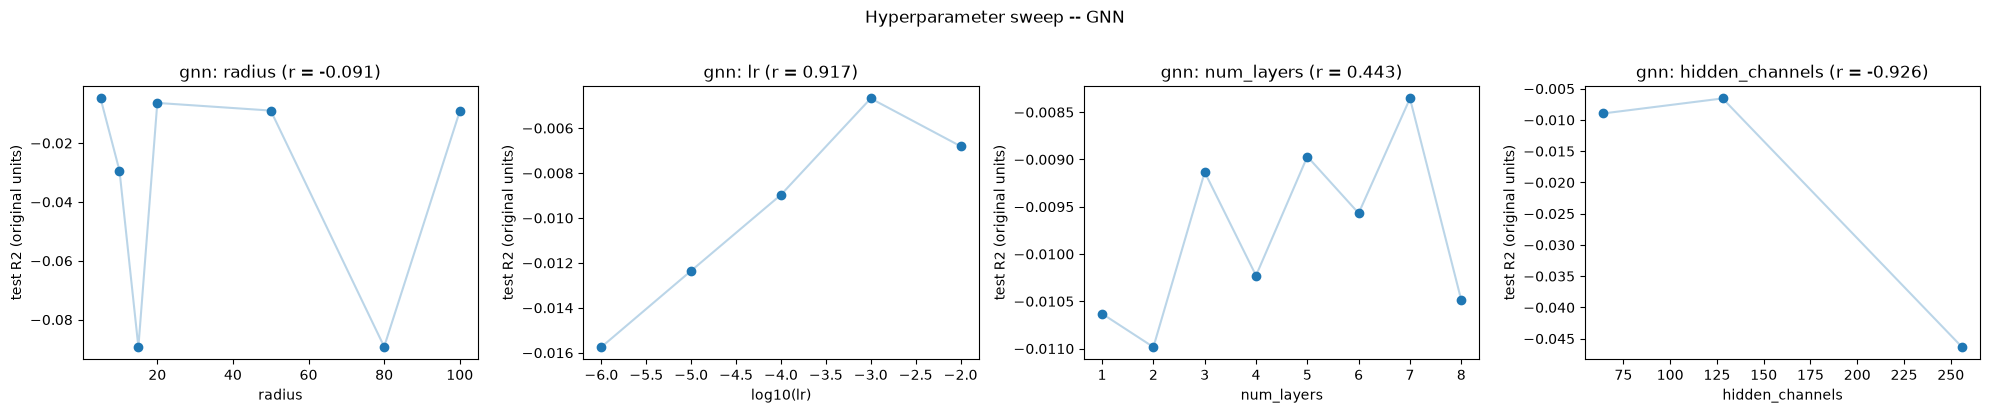

In [10]:
MODEL_TYPE = 'gnn' 

RADIUS_VALUES = [5, 10, 15, 20, 50, 80, 100]
LR_VALUES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
NUM_LAYERS_VALUES = [1, 2, 3, 4, 5, 6, 7, 8]
HIDDEN_DIMS = [64, 128, 256]
SEED = 0

BASE_LR = 1e-4
BASE_NUM_LAYERS = 5
BASE_HIDDEN = 64
BASE_RADIUS = 50

sweep_results = {'radius': [], 'lr': [], 'num_layers': [], 'hidden_channels': []}
for r in RADIUS_VALUES:
    sweep_results['radius'].append((r, run_sweep(MODEL_TYPE, radius=r, lr=BASE_LR, num_layers=BASE_NUM_LAYERS, hidden_channels=BASE_HIDDEN)))
for lr in LR_VALUES:
    sweep_results['lr'].append((lr, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=lr, num_layers=BASE_NUM_LAYERS, hidden_channels=BASE_HIDDEN)))
for nl in NUM_LAYERS_VALUES:
    sweep_results['num_layers'].append((nl, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=BASE_LR, num_layers=nl, hidden_channels=BASE_HIDDEN)))
for hd in HIDDEN_DIMS:
    sweep_results['hidden_channels'].append((hd, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=BASE_LR, num_layers=BASE_NUM_LAYERS, hidden_channels=hd)))

# ---- one subplot per hyperparameter, R2 vs. value, with a correlation coefficient ----
fig, axes = plt.subplots(1, len(sweep_results), figsize=(5 * len(sweep_results), 4))
for ax, (name, pairs) in zip(axes, sweep_results.items()):
    xs, ys = zip(*pairs)
    xs_plot = np.log10(xs) if name == 'lr' else xs
    ax.scatter(xs_plot, ys)
    ax.plot(xs_plot, ys, alpha=0.3)
    corr = np.corrcoef(xs_plot, ys)[0, 1]
    ax.set_xlabel('log10(lr)' if name == 'lr' else name)
    ax.set_ylabel('test R2 (original units)')
    ax.set_title(f'{MODEL_TYPE}: {name} (r = {corr:.3f})')
fig.suptitle(f'Hyperparameter sweep -- {MODEL_TYPE.upper()}', y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
MODEL_TYPE = 'gat'  # 'gnn' | 'gat' -- GAT is much slower, especially at num_layers > 1 (multi-head attention)

RADIUS_VALUES = [20, 50, 80, 100, 120, 150, 200, 300]
LR_VALUES = [1e-4, 1e-3, 1e-2]
NUM_LAYERS_VALUES = [1, 2, 3, 4, 5, 6, 7, 8]
HIDDEN_DIMS = [64, 128, 256]
HEADS_VALUES = [1, 2, 4, 8]  # only affects GAT, and only bites when num_layers > 1 (see run_sweep docstring)
SEED = 0

BASE_LR = 1e-3
BASE_NUM_LAYERS = 5
BASE_HIDDEN = 64
BASE_RADIUS = 50
BASE_HEADS = 4

sweep_results = {'radius': [], 'lr': [], 'num_layers': [], 'hidden_channels': [], 'heads': []}
for r in RADIUS_VALUES:
    sweep_results['radius'].append((r, run_sweep(MODEL_TYPE, radius=r, lr=BASE_LR, num_layers=BASE_NUM_LAYERS, hidden_channels=BASE_HIDDEN, heads=BASE_HEADS)))
for lr in LR_VALUES:
    sweep_results['lr'].append((lr, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=lr, num_layers=BASE_NUM_LAYERS, hidden_channels=BASE_HIDDEN, heads=BASE_HEADS)))
for nl in NUM_LAYERS_VALUES:
    sweep_results['num_layers'].append((nl, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=BASE_LR, num_layers=nl, hidden_channels=BASE_HIDDEN, heads=BASE_HEADS)))
for hd in HIDDEN_DIMS:
    sweep_results['hidden_channels'].append((hd, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=BASE_LR, num_layers=BASE_NUM_LAYERS, hidden_channels=hd, heads=BASE_HEADS)))
for h in HEADS_VALUES:
    sweep_results['heads'].append((h, run_sweep(MODEL_TYPE, radius=BASE_RADIUS, lr=BASE_LR, num_layers=BASE_NUM_LAYERS, hidden_channels=BASE_HIDDEN, heads=h)))

# ---- one subplot per hyperparameter, R2 vs. value, with a correlation coefficient ----
fig, axes = plt.subplots(1, len(sweep_results), figsize=(5 * len(sweep_results), 4))
for ax, (name, pairs) in zip(axes, sweep_results.items()):
    xs, ys = zip(*pairs)
    xs_plot = np.log10(xs) if name == 'lr' else xs
    ax.scatter(xs_plot, ys)
    ax.plot(xs_plot, ys, alpha=0.3)
    corr = np.corrcoef(xs_plot, ys)[0, 1]
    ax.set_xlabel('log10(lr)' if name == 'lr' else name)
    ax.set_ylabel('test R2 (original units)')
    ax.set_title(f'{MODEL_TYPE}: {name} (r = {corr:.3f})')
fig.suptitle(f'Hyperparameter sweep -- {MODEL_TYPE.upper()}', y=1.02)
fig.tight_layout()
plt.show()

In [38]:
import gc
import torch

gc.collect()
torch.mps.empty_cache()

### Prediction

In [ ]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_loss_curves, local_density
from models.gnn import build_prediction_data, train_predictor, IFPredictor, predict_df as gnn_predict_df, border_mask, save_model
from models.gat import IFPredictorGAT

PRED_RADIUS = 100  # px -- create a graph (every pair within radius is connected), NOT k-NN
DENSITY_RADIUS = 50 # compute number of cells within this radius as feature
NUM_LAYERS = 4
NORMALIZE_DATA = False
HIDDEN_DIM = 128
LR = 1e-4
NUM_HEADS = 2
DISTANCE_INIT = True

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
cell_df['local_density'] = local_density(centroids, radius=DENSITY_RADIUS)  # same neighborhood as the graph itself

# Cells within PRED_RADIUS of the image edge have an undercounted neighborhood -- part
# of their disk was never imaged, not empty -- so exclude them from ever being a
# train/val/test TARGET. They're NOT removed from the data: they stay in the graph and
# still act as a neighbor for cells further from the edge, just never trained on/evaluated.
is_border = border_mask(centroids, cell_mask.shape, PRED_RADIUS)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {PRED_RADIUS}px of the border -- excluded as targets')

train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

# Self (BMP4_mean) now reaches its own embedding directly via the radius graph's
# self-loop (models.gnn.build_radius_graph) -- one column in, one pathway, no more
# separate global_x_cols/neighbor_x_cols split.
pred_data = build_prediction_data(
    cell_df, if_cols, radius=PRED_RADIUS, x_cols=X_COLS, train_idx=train_idx, scaling=SCALING,
    y_cols=Y_COLS,
    no_background_cols=['local_density'],
    no_transform_cols=['local_density'],
    normalize_data=NORMALIZE_DATA,
)
print("x_cols (self + neighbors, via the graph's self-loop):", pred_data['x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells, {pred_data['edge_index'].shape[1]} directed edges incl. self-loops (radius={PRED_RADIUS}px)")

In [ ]:
# check if the dynamic range is good enough for prediction
data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
for i, x in enumerate(pred_data['x_cols']):
    data[x] = pred_data['x'][:, i]

data['centroid_x'] = cell_df['centroid_x'].values
data['centroid_y'] = cell_df['centroid_y'].values
print(data.shape)
data.tail(2)

In [10]:
# data.to_csv(f'../data/training/{img_name}_scaled.csv')

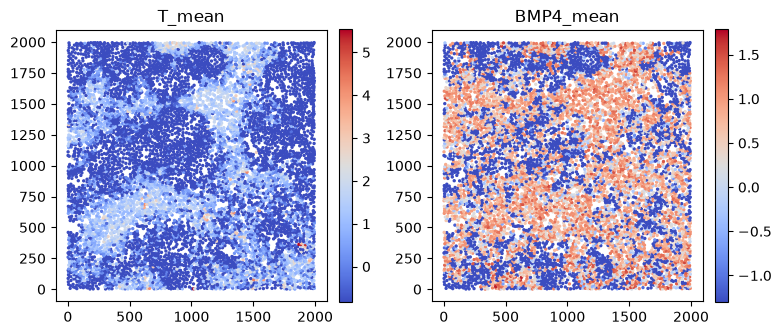

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs = axs.flatten()

for i, col in enumerate(cols):
    ax = axs[i]
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=2
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)

fig.tight_layout()
plt.savefig(f'{fig_dir}/features.png', dpi=300)
plt.show()

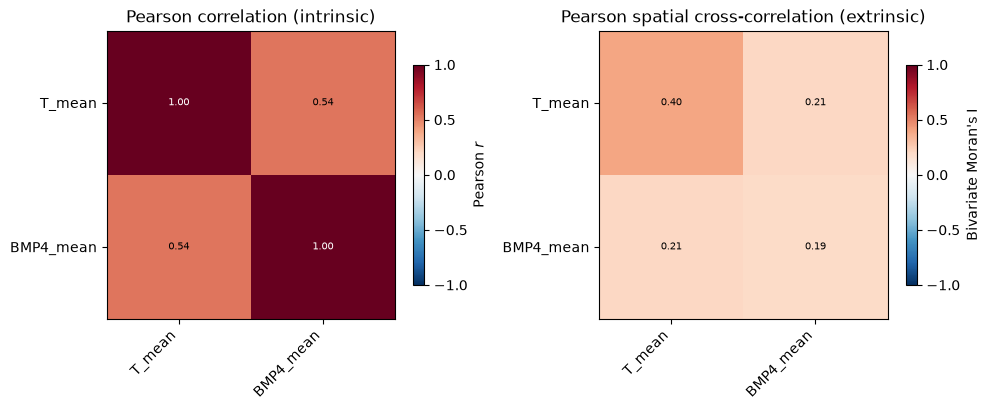

In [12]:
from tools.morphology import plot_correlation_heatmap, plot_spatial_cross_correlation

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_correlation_heatmap(data, cols, title=f'Pearson correlation (intrinsic)', corr_type='pearson', ax=axs[0])
plot_spatial_cross_correlation(data, cols, title='Pearson spatial cross-correlation (extrinsic)', corr_type='pearson', edge_index=pred_data['edge_index'], ax=axs[1])
plt.tight_layout()

In [ ]:
GNN_KWARGS = dict(
    in_channels=len(pred_data['x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS, 
    hidden_channels=HIDDEN_DIM,
    normalize_data=NORMALIZE_DATA
)

torch.manual_seed(SEED)
gnn_model = IFPredictor(**GNN_KWARGS)
gnn_history = train_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN', 
    epochs=500, lr=LR
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title='Self+neighbor -> IF prediction (radius GNN)')
plt.show()

# Original units (default) -- predict_df now returns (pred_df, true_df) together, both
# in the same units, same y_scaler=None toggle as models.cnn.predict_patch_df.
gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
display(gnn_r2)
fig_gnn_pred = plot_pred_vs_actual(gnn_true_test, gnn_pred_test, title='GNN, test set')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gnn.pt', gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA,
)

In [ ]:
GAT_KWARGS = dict(
    in_channels=len(pred_data['x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS,
    hidden_channels=HIDDEN_DIM,
    heads=NUM_HEADS,
    distance_init=DISTANCE_INIT
)

torch.manual_seed(SEED)
gat_model = IFPredictorGAT(**GAT_KWARGS)
gat_history = train_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=500, lr=LR, patience=100
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title='Self+neighbor -> IF prediction (radius GAT)')
plt.show()

gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
display(gat_r2)
fig_gat_pred = plot_pred_vs_actual(gat_true_test, gat_pred_test, title='GAT, test set')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gat.pt', gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA
)

In [ ]:
comparison = pd.concat({'GNN (fixed weights)': gnn_r2, 'GAT (learned attention)': gat_r2}, axis=1)
display(comparison)

### Understanding the GAT: attention weights

`WeightedRadiusConv` (the fixed-weight GNN) weights every neighbor -- and self, via
its self-loop -- by a deterministic function of distance alone -- there's nothing to
"interpret" there beyond the decay curve itself. `GATConv` (the GAT) instead LEARNS
its weighting, so inspecting those learned attention weights directly shows what the
model actually uses, rather than assuming distance is what matters.

`GATConv` hands back the exact per-edge attention coefficient via
`return_attention_weights=True` -- softmax-normalized so each cell's incoming
attention still sums to 1, same property as the fixed GNN's `edge_weight`, just
learned instead of fixed. Two things worth checking:
- **Attention vs. distance**: if attention just tracks the same exponential decay the
  fixed GNN assumes, geometry is doing all the work and the learned attention isn't
  adding anything beyond it. If it doesn't correlate with distance, the model has
  found something in the marker values themselves that geometry alone can't explain.
- **Per-cell attention map**: for one example cell, which of its neighbors (or itself,
  via the self-loop) does the model actually lean on -- the physically closest ones,
  or ones with a similar/dissimilar marker profile regardless of exact distance?

In [ ]:
edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.RadiusGAT.attention_by_layer) --
# with NUM_LAYERS > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used. `E` includes
# each cell's own self-loop edge (distance 0) alongside its neighbors'.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# x_cols values; deeper layers' attention operates on the embeddings that
# resulted from earlier layers, so a correlation there reflects an indirect/aggregate
# relationship with the raw marker, not a direct one.
x_cols = pred_data['x_cols']
n_panels = 1 + len(x_cols)
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px) -- 0 == self-loop')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(x_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and marker value, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell below (single-example-cell map) uses the FINAL layer's attention -- the one
# that most directly determines what reaches the prediction head.
att_weights = layer_attentions[-1]

In [ ]:
# One example (held-out test) cell: one attention-weight panel PER LAYER (positions are
# identical across layers -- only the coloring/attention values change, since layer 1's
# attention is a genuinely different, separately-learned quantity from layer 0's, see
# the "distance and marker value, by layer" cell above), then one panel per marker
# column (these don't depend on layer at all, so shown once rather than repeated).
example_cell_pos = test_idx[0]
mask_edges = (dst == example_cell_pos)
field_pos = src[mask_edges].numpy()  # includes the self-loop -- one of these IS example_cell_pos itself

n_layers = len(layer_attentions)
n_panels = n_layers + len(x_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    field_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=field_att, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(x_cols):
    ax = axes[n_layers + j]
    values = pred_data['x'][field_pos, j].numpy()
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. marker value (self + neighbors): cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example.png', dpi=300, bbox_inches='tight')
plt.show()